In this notebook we explore Gaussian Process Latent Variable Models (GPLVM) from Pyro for processing ESR data. GPLVM combines latent variable models with GPs to learn lower-dimensional representations while enabling precise spectra -> temperature mapping across measurement cycles.

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
pip install GPy

In [26]:
# import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, grid, tight_layout
import datetime
import GPy
from sklearn.preprocessing import MinMaxScaler

# Make the Jupyter Notebook fill 90 percent of the screen
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


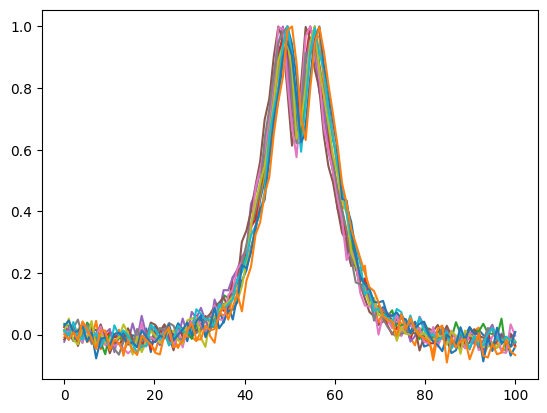

In [27]:
# load cycle 1 data and preprocess it

temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
c1_temps = np.array(temps_, dtype=float)

## import data file
fpath = '/content/drive/MyDrive/gaussian_process/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0);
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100

# plot baseline subtracted  y data
y_esr_c1 = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr_c1 = y_esr_c1/y_esr_c1.min()
y_esr_c1 = y_esr_c1.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c1);
#plt.xlim(40, 80)


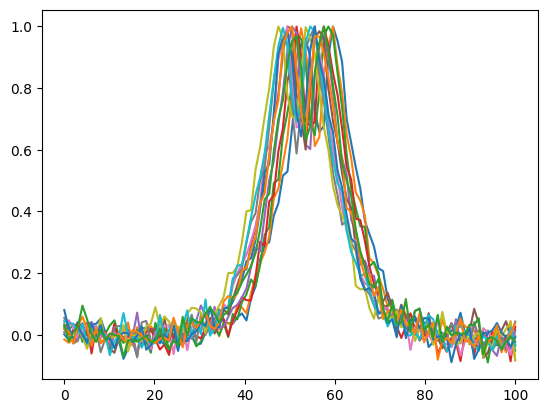

In [28]:
# load cycle 2 data and preprocess it

temps_ = ['-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30']

c2_temps = np.array(temps_[:-4], dtype=float)


## import data file
fpath = '/content/drive/MyDrive/gaussian_process/cycle2'

df_= pd.read_csv(fpath, sep=',', header = 0);
df= df_.iloc[0:, 1:-4]
#df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis
x_esr = df.frequency.values
y_esr_c2 = df.iloc[:, 1:]

# plt.plot(x_scale, y_esr_c2); plt.show()
#plt.xlim(40, 80)

y_esr_c2 = y_esr_c2.apply(lambda x: x - x[:20].mean())#+0.01
y_esr_c2 = y_esr_c2/y_esr_c2.min()
y_esr_c2 = y_esr_c2.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c2);



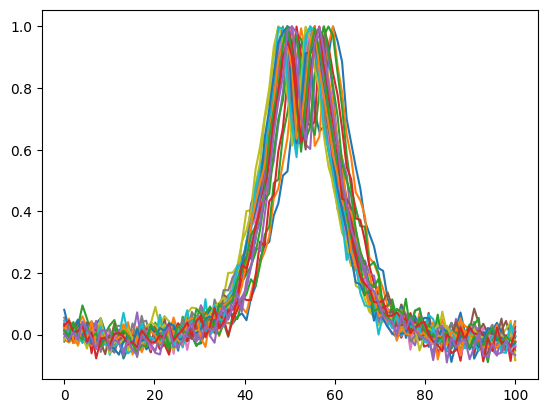

In [29]:
plt.plot(x_scale, y_esr_c2);
plt.plot(x_scale, y_esr_c1);

In [30]:
# Prepare data for GPy GPLVM: Convert to numpy arrays in correct format (N_samples, N_features)

# C1: 12 samples x 100 features
X_c1 = y_esr_c1.T.values  # Shape: (12, 100)
Y_c1_temps = c1_temps.reshape(-1, 1)  # Shape: (12, 1) - temperatures as column vector

# C2: 13 samples x 100 features
X_c2 = y_esr_c2.T.values  # Shape: (13, 100)
Y_c2_temps = c2_temps.reshape(-1, 1)  # Shape: (13, 1) - temperatures as column vector

print(f"C1 spectra shape: {X_c1.shape}, temperatures shape: {Y_c1_temps.shape}")
print(f"C2 spectra shape: {X_c2.shape}, temperatures shape: {Y_c2_temps.shape}")
print(f"\nC1 temperatures: {Y_c1_temps.flatten()}")
print(f"C2 temperatures: {Y_c2_temps.flatten()}")

C1 spectra shape: (12, 100), temperatures shape: (12, 1)
C2 spectra shape: (13, 100), temperatures shape: (13, 1)

C1 temperatures: [25. 30. 35. 40. 45. 50. 45. 40. 35. 30. 25. 20.]
C2 temperatures: [-30. -20. -10.   0.  10.  20.  30.  40.  50.  40.  30.  20.  10.]


In [31]:
# Stage 1: Fit GPLVM on C2 spectra (unsupervised dimensionality reduction)
# Learn a low-dimensional latent representation of C2 ESR spectra

# Set random seed for reproducibility
np.random.seed(42)

# Define latent dimensionality
latent_dim_c2 = 3  # Learn 3-dimensional latent space

# Initialize GPLVM model for C2
# Input: C2 ESR spectra (13 x 100)
# Output: Latent codes (13 x 3)
print("Fitting GPLVM to C2 spectra (13 samples, 100 features)...")
gplvm_c2 = GPy.models.GPLVM(X_c2, latent_dim_c2, kernel=GPy.kern.RBF(latent_dim_c2, ARD=True))

# Optimize GPLVM parameters
print("Optimizing GPLVM for C2...")
gplvm_c2.optimize(messages=True, max_iters=500)

# Extract latent representations for C2
Z_c2 = gplvm_c2.X.copy()  # Shape: (13, 3)
print(f"C2 latent codes shape: {Z_c2.shape}")
print(f"C2 latent codes:\n{Z_c2}")

Fitting GPLVM to C2 spectra (13 samples, 100 features)...
Optimizing GPLVM for C2...


C2 latent codes shape: (13, 3)
C2 latent codes:
  index    |  latent_mean  |  constraints  |  priors
  [0 0]    |  -1.10103299  |               |        
  [0 1]    |  -0.59131555  |               |        
  [0 2]    |   0.44055872  |               |        
  [1 0]    |  -1.00515458  |               |        
  [1 1]    |  -0.41350997  |               |        
  [1 2]    |   0.05879148  |               |        
  [2 0]    |  -0.85963204  |               |        
  [2 1]    |  -0.11569702  |               |        
  [2 2]    |  -0.14903348  |               |        
  [3 0]    |  -0.66657209  |               |        
  [3 1]    |   0.23338539  |               |        
  [3 2]    |  -0.16617718  |               |        
  [4 0]    |  -0.23815411  |               |        
  [4 1]    |   0.44242270  |               |        
  [4 2]    |  -0.30967752  |               |        
  [5 0]    |   0.21951427  |               |        
  [5 1]    |   0.34749739  |               |       

In [32]:
# Stage 2a: Fit GPy GP regression - C2 latent codes to temperatures
# Train: C2 latents → C2 temperatures

print("\nFitting GP regression on C2 latent codes to temperatures...")
gp_c2_temp = GPy.models.GPRegression(Z_c2, Y_c2_temps, kernel=GPy.kern.RBF(latent_dim_c2, ARD=True))

# Optimize GP regression
print("Optimizing GP regression for C2...")
gp_c2_temp.optimize(messages=True, max_iters=100)

print(f"\nGP C2 model summary:")
print(gp_c2_temp)

# Get predictions on C2 training data (should fit well)
mu_c2_train, var_c2_train = gp_c2_temp.predict(Z_c2)
std_c2_train = np.sqrt(var_c2_train)

mae_c2_train = np.mean(np.abs(mu_c2_train.flatten() - Y_c2_temps.flatten()))
rmse_c2_train = np.sqrt(np.mean((mu_c2_train.flatten() - Y_c2_temps.flatten())**2))
print(f"\nC2 Training Set Performance (GP on latents):")
print(f"MAE: {mae_c2_train:.4f} °C")
print(f"RMSE: {rmse_c2_train:.4f} °C")


Fitting GP regression on C2 latent codes to temperatures...
Optimizing GP regression for C2...



GP C2 model summary:

Name : GP regression
Objective : 44.34154030765907
Number of Parameters : 5
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |               value  |  constraints  |  priors
  rbf.variance             |   9684.926627845278  |      +ve      |        
  rbf.lengthscale          |                (3,)  |      +ve      |        
  Gaussian_noise.variance  |  16.381901407680296  |      +ve      |        

C2 Training Set Performance (GP on latents):
MAE: 2.9313 °C
RMSE: 3.6599 °C


 /usr/local/lib/python3.12/dist-packages/GPy/kern/src/stationary.py:137: RuntimeWarning:overflow encountered in square
 /usr/local/lib/python3.12/dist-packages/GPy/kern/src/stationary.py:138: RuntimeWarning:invalid value encountered in add
 /usr/local/lib/python3.12/dist-packages/GPy/kern/src/rbf.py:178: RuntimeWarning:invalid value encountered in multiply


In [33]:
# Stage 2b: Cross-validation prediction (Train on C2, Test on C1)
# Find C1 latent codes using the trained C2 GPLVM, then predict temperatures

print("\n" + "="*60)
print("CROSS-VALIDATION: Train on C2, Test on C1")
print("="*60)

# Initialize latent codes for C1 using random values
Z_c1_init = np.random.randn(X_c1.shape[0], latent_dim_c2) * 0.1

# Create a temporary GPLVM model for C1 using the trained C2 kernel
# This will optimize only the C1 latent codes while keeping the GPLVM parameters fixed
print("\nEncoding C1 spectra using trained C2 GPLVM...")

# Optimize C1 latent codes to match C1 spectra using the trained C2 GPLVM model
gplvm_c1_encoded = GPy.models.GPLVM(X_c1, latent_dim_c2, kernel=gplvm_c2.kern.copy())
gplvm_c1_encoded.likelihood.variance = gplvm_c2.likelihood.variance.copy()

# Fix kernel parameters (use trained C2 parameters)
gplvm_c1_encoded.kern.parameters = gplvm_c2.kern.parameters.copy()

# # Optimize only the latent codes Z for C1
# gplvm_c1_encoded.Z[:] = Z_c1_init
print("Optimizing C1 latent codes (keeping GPLVM parameters fixed)...")
gplvm_c1_encoded.optimize_restarts(num_restarts=5, messages=False, max_iters=500, robust=True)

# Extract C1 latent codes
Z_c1 = gplvm_c1_encoded.X.copy()  # Shape: (12, 3)
print(f"C1 latent codes shape: {Z_c1.shape}")
print(f"C1 latent codes:\n{Z_c1}")

# Predict C1 temperatures using the trained C2 GP regression model
print("\nPredicting C1 temperatures using trained C2 temperature model...")
mu_c1_pred, var_c1_pred = gp_c2_temp.predict(Z_c1)
std_c1_pred = np.sqrt(var_c1_pred)

# Performance metrics for C2→C1
mae_c2_c1 = np.mean(np.abs(mu_c1_pred.flatten() - Y_c1_temps.flatten()))
rmse_c2_c1 = np.sqrt(np.mean((mu_c1_pred.flatten() - Y_c1_temps.flatten())**2))

print(f"\nC2→C1 Prediction Performance (GPLVM + GP on latents):")
print(f"Mean Absolute Error: {mae_c2_c1:.4f} °C")
print(f"RMSE: {rmse_c2_c1:.4f} °C")
print(f"Mean prediction std: {np.mean(std_c1_pred):.6f}")


CROSS-VALIDATION: Train on C2, Test on C1

Encoding C1 spectra using trained C2 GPLVM...
Optimizing C1 latent codes (keeping GPLVM parameters fixed)...
Optimization restart 1/5, f = -2150.3981248237683
Optimization restart 2/5, f = -2150.3981250745837
Optimization restart 3/5, f = -2150.3981249651483
Optimization restart 4/5, f = -2150.3981251855876
Optimization restart 5/5, f = -2150.3981237867997
C1 latent codes shape: (12, 3)
C1 latent codes:
  index    |    latent_mean  |  constraints  |  priors
  [0 0]    |    -0.12348203  |               |        
  [0 1]    |    -0.54878527  |               |        
  [0 2]    |     0.44841589  |               |        
  [1 0]    |     0.04707853  |               |        
  [1 1]    |    -0.06862813  |               |        
  [1 2]    |     0.33494333  |               |        
  [2 0]    |     0.09279191  |               |        
  [2 1]    |     0.39768943  |               |        
  [2 2]    |    -0.06035165  |               |        

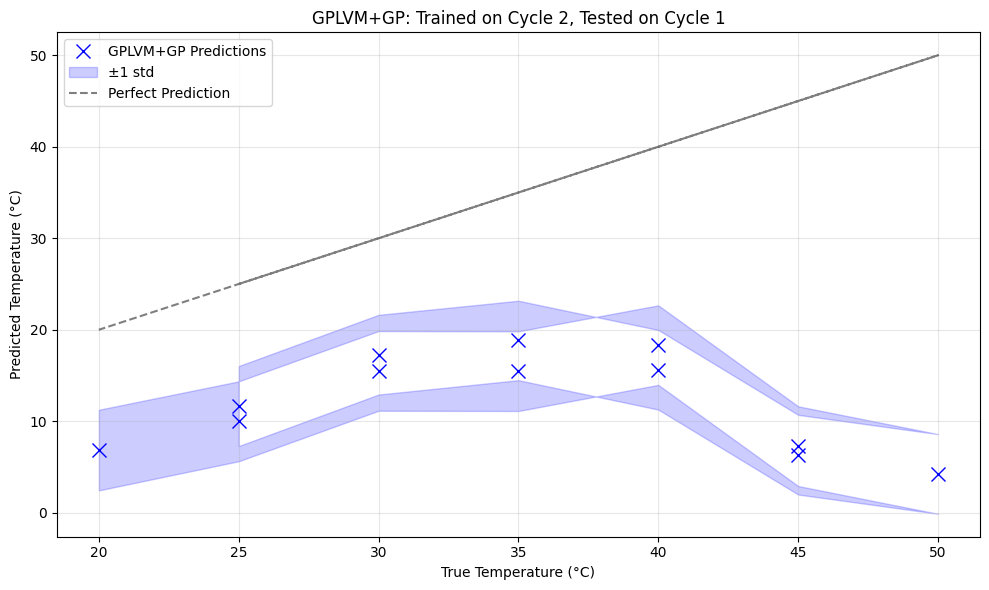

In [34]:
# Visualization: C2→C1 prediction results

plt.figure(figsize=(10, 6))
plt.plot(Y_c1_temps.flatten(), mu_c1_pred.flatten(), 'x', label='GPLVM+GP Predictions', markersize=10, color='blue')
plt.fill_between(Y_c1_temps.flatten(),
                 (mu_c1_pred - std_c1_pred).flatten(),
                 (mu_c1_pred + std_c1_pred).flatten(),
                 alpha=0.2, color='blue', label='±1 std')
plt.plot(Y_c1_temps.flatten(), Y_c1_temps.flatten(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('GPLVM+GP: Trained on Cycle 2, Tested on Cycle 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Flipped Configuration: Train GPLVM on C1, Test on C2

In [35]:
# Stage 1: Fit GPLVM on C1 spectra (unsupervised dimensionality reduction)
# Learn a low-dimensional latent representation of C1 ESR spectra

# Define latent dimensionality for C1
latent_dim_c1 = 3

# Initialize GPLVM model for C1
print("\n" + "="*60)
print("FITTING GPLVM TO C1 SPECTRA")
print("="*60)
print("Fitting GPLVM to C1 spectra (12 samples, 100 features)...")
gplvm_c1 = GPy.models.GPLVM(X_c1, latent_dim_c1, kernel=GPy.kern.RBF(latent_dim_c1, ARD=True))

# Optimize GPLVM parameters
print("Optimizing GPLVM for C1...")
gplvm_c1.optimize(messages=True, max_iters=1000)

# Extract latent representations for C1
Z_c1_native = gplvm_c1.X.copy()  # Shape: (12, 3)
print(f"C1 latent codes shape: {Z_c1_native.shape}")
print(f"C1 latent codes:\n{Z_c1_native}")

# Stage 2a: Fit GPy GP regression - C1 latent codes to temperatures
print("\nFitting GP regression on C1 latent codes to temperatures...")
gp_c1_temp = GPy.models.GPRegression(Z_c1_native, Y_c1_temps, kernel=GPy.kern.RBF(latent_dim_c1, ARD=True))

# Optimize GP regression
print("Optimizing GP regression for C1...")
gp_c1_temp.optimize(messages=True, max_iters=1000)

print(f"\nGP C1 model summary:")
print(gp_c1_temp)

# Get predictions on C1 training data
mu_c1_train, var_c1_train = gp_c1_temp.predict(Z_c1_native)
std_c1_train = np.sqrt(var_c1_train)

mae_c1_train = np.mean(np.abs(mu_c1_train.flatten() - Y_c1_temps.flatten()))
rmse_c1_train = np.sqrt(np.mean((mu_c1_train.flatten() - Y_c1_temps.flatten())**2))
print(f"\nC1 Training Set Performance (GP on latents):")
print(f"MAE: {mae_c1_train:.4f} °C")
print(f"RMSE: {rmse_c1_train:.4f} °C")


FITTING GPLVM TO C1 SPECTRA
Fitting GPLVM to C1 spectra (12 samples, 100 features)...
Optimizing GPLVM for C1...


C1 latent codes shape: (12, 3)
C1 latent codes:
  index    |   latent_mean  |  constraints  |  priors
  [0 0]    |   -0.51291094  |               |        
  [0 1]    |    0.05451240  |               |        
  [0 2]    |   -0.04449675  |               |        
  [1 0]    |   -0.24615662  |               |        
  [1 1]    |    0.06941977  |               |        
  [1 2]    |    0.07915351  |               |        
  [2 0]    |    0.10290529  |               |        
  [2 1]    |    0.16412921  |               |        
  [2 2]    |    0.01482857  |               |        
  [3 0]    |    0.30292125  |               |        
  [3 1]    |    0.02254108  |               |        
  [3 2]    |    0.05202751  |               |        
  [4 0]    |    0.44309419  |               |        
  [4 1]    |    0.00730711  |               |        
  [4 2]    |   -0.18594053  |               |        
  [5 0]    |    0.70079725  |               |        
  [5 1]    |   -0.27790800  |     


GP C1 model summary:

Name : GP regression
Objective : 25.29486732753864
Number of Parameters : 5
Number of Optimization Parameters : 5
Updates : True
Parameters:
  GP_regression.           |               value  |  constraints  |  priors
  rbf.variance             |   5172.172047393034  |      +ve      |        
  rbf.lengthscale          |                (3,)  |      +ve      |        
  Gaussian_noise.variance  |  0.7977094245567307  |      +ve      |        

C1 Training Set Performance (GP on latents):
MAE: 0.5939 °C
RMSE: 0.7836 °C


In [36]:
# Stage 2b: Cross-validation prediction (Train on C1, Test on C2)
# Find C2 latent codes using the trained C1 GPLVM, then predict temperatures

print("\n" + "="*60)
print("CROSS-VALIDATION: Train on C1, Test on C2")
print("="*60)

# Initialize latent codes for C2 using random values
Z_c2_init = np.random.randn(X_c2.shape[0], latent_dim_c1) * 0.1

# Create a temporary GPLVM model for C2 using the trained C1 kernel
print("\nEncoding C2 spectra using trained C1 GPLVM...")

# Create GPLVM for C2 with C1's trained kernelparameters
gplvm_c2_encoded = GPy.models.GPLVM(X_c2, latent_dim_c1, kernel=gplvm_c1.kern.copy())
gplvm_c2_encoded.likelihood.variance = gplvm_c1.likelihood.variance.copy()

# Fix kernel parameters (use trained C1 parameters)
gplvm_c2_encoded.kern.parameters = gplvm_c1.kern.parameters.copy()

# Optimize only the latent codes Z for C2
gplvm_c2_encoded.Z[:] = Z_c2_init
print("Optimizing C2 latent codes (keeping GPLVM parameters fixed)...")
gplvm_c2_encoded.optimize_restarts(num_restarts=5, messages=False, max_iters=500, robust=True)

# Extract C2 latent codes
Z_c2_native = gplvm_c2_encoded.X.copy()  # Shape: (13, 3)
print(f"C2 latent codes shape: {Z_c2_native.shape}")
print(f"C2 latent codes:\n{Z_c2_native}")

# Predict C2 temperatures using the trained C1 GP regression model
print("\nPredicting C2 temperatures using trained C1 temperature model...")
mu_c2_pred, var_c2_pred = gp_c1_temp.predict(Z_c2_native)
std_c2_pred = np.sqrt(var_c2_pred)

# Performance metrics for C1→C2
mae_c1_c2 = np.mean(np.abs(mu_c2_pred.flatten() - Y_c2_temps.flatten()))
rmse_c1_c2 = np.sqrt(np.mean((mu_c2_pred.flatten() - Y_c2_temps.flatten())**2))

print(f"\nC1→C2 Prediction Performance (GPLVM + GP on latents):")
print(f"Mean Absolute Error: {mae_c1_c2:.4f} °C")
print(f"RMSE: {rmse_c1_c2:.4f} °C")
print(f"Mean prediction std: {np.mean(std_c2_pred):.6f}")


CROSS-VALIDATION: Train on C1, Test on C2

Encoding C2 spectra using trained C1 GPLVM...


AttributeError: 'GPLVM' object has no attribute 'Z'

In [ ]:
# Visualization: C1→C2 prediction results

plt.figure(figsize=(10, 6))
plt.plot(Y_c2_temps.flatten(), mu_c2_pred.flatten(), 'x', label='GPLVM+GP Predictions', markersize=10, color='red')
plt.fill_between(Y_c2_temps.flatten(),
                 (mu_c2_pred - std_c2_pred).flatten(),
                 (mu_c2_pred + std_c2_pred).flatten(),
                 alpha=0.2, color='red', label='±1 std')
plt.plot(Y_c2_temps.flatten(), Y_c2_temps.flatten(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('GPLVM+GP: Trained on Cycle 1, Tested on Cycle 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Performance Summary: Compare both cross-validation scenarios

print("\n" + "="*70)
print("PERFORMANCE SUMMARY - GPLVM + GPy GP Regression")
print("="*70)
print("\nTRAINING SET PERFORMANCE:")
print(f"  C2 Training (on latents): MAE = {mae_c2_train:.4f} °C, RMSE = {rmse_c2_train:.4f} °C")
print(f"  C1 Training (on latents): MAE = {mae_c1_train:.4f} °C, RMSE = {rmse_c1_train:.4f} °C")

print("\nCROSS-VALIDATION PERFORMANCE:")
print(f"  C2 → C1 (trained on C2): MAE = {mae_c2_c1:.4f} °C, RMSE = {rmse_c2_c1:.4f} °C")
print(f"  C1 → C2 (trained on C1): MAE = {mae_c1_c2:.4f} °C, RMSE = {rmse_c1_c2:.4f} °C")

print("\nLATENT SPACE DIMENSIONALITY:")
print(f"  C1 latent dimension: {latent_dim_c1} (reduced from 100 features)")
print(f"  C2 latent dimension: {latent_dim_c2} (reduced from 100 features)")
print(f"  Dimensionality reduction: {100/latent_dim_c1:.1f}x for C1, {100/latent_dim_c2:.1f}x for C2")

print("\nMODEL COMPONENTS:")
print(f"  Unsupervised: GPLVM (learns latent representation)")
print(f"  Supervised: GPy GP regression (latent codes → temperature)")
print("="*70)

In [ ]:
# Convert to torch tensors for GP: Train on Cycle 2, Test on Cycle 1
X_train = torch.tensor(y_esr_c2.T.values, dtype=torch.float64)
y_train = torch.tensor(c2_temps, dtype=torch.float64)
X_test = torch.tensor(y_esr_c1.T.values, dtype=torch.float64)
y_test = torch.tensor(c1_temps, dtype=torch.float64)

print(f"Training data (C2): X shape {X_train.shape}, y shape {y_train.shape}")
print(f"Test data (C1): X shape {X_test.shape}, y shape {y_test.shape}")

In [ ]:
# Initialize GP regression model with spectral features as inputs
# Don't use GPLVM - instead use SparseGPRegression directly

# Create inducing points in spectral feature space
num_inducing = min(32, X_train.shape[0] // 2)
Uu_init = torch.randn(num_inducing, X_train.shape[1]) * 0.1

# Define RBF kernel for feature space
kernel = RBF(input_dim=X_train.shape[1])

# Reshape y_train to (output_dim, num_data_points) format expected by Pyro
y_train_gp = y_train.unsqueeze(0)  # Shape: (1, 13) - 1 output dimension, 13 data points

# Create SparseGPRegression model directly on spectral features
model = SparseGPRegression(
    X=X_train,  # Shape: (13, 100) - spectral features as direct input
    y=y_train_gp,  # Shape: (1, 13)
    kernel=kernel,
    Xu=Uu_init,  # Inducing points in feature space
    noise=torch.tensor(0.01),
    jitter=1e-5
)

print(f"SparseGPRegression initialized for spectral feature regression")
print(f"Data shapes - X: {X_train.shape}, y: {y_train_gp.shape}")
print(f"Inducing points shape: {Uu_init.shape}")

In [ ]:
### Fit GP on C2 and make predictions on C1

# Reset parameter store
pyro.clear_param_store()

# Create SVI optimizer using Pyro's optimizer wrapper
optimizer = optim.Adam({"lr": 0.01})

# Create the ELBO loss function
elbo = TraceMeanField_ELBO()

# Setup SVI
svi = SVI(model.model, model.guide, optimizer, loss=elbo)

# Training loop
num_steps = 200
losses = []

print("Training SparseGPRegression...")
for step in range(num_steps):
    loss = svi.step()

    if step % 40 == 0:
        print(f"Step {step}: Loss = {loss:.4f}")
        losses.append(loss)

print(f"Training complete! Final loss: {loss:.4f}")

# Make predictions on test set (C1) using learned model
with torch.no_grad():
    model.set_mode("guide")
    mu, var = model(X_test)

    mu = mu.squeeze().numpy().flatten()
    std = np.sqrt(var.squeeze().numpy().flatten())

In [ ]:
# Performance metrics for C2->C1
mae_c2_c1 = np.mean(np.abs(mu - y_test.numpy()))
rmse_c2_c1 = np.sqrt(np.mean((mu - y_test.numpy())**2))
print(f"Mean Absolute Error: {mae_c2_c1:.4f} °C")
print(f"RMSE: {rmse_c2_c1:.4f} °C")
print(f"Mean prediction std: {np.mean(std):.6f}")

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.numpy(), mu, 'x', label='GP Predictions', markersize=10)
plt.fill_between(y_test.numpy(), mu - std, mu + std, alpha=0.2, color='blue', label='±1 std')
plt.plot(y_test.numpy(), y_test.numpy(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('SparseGP: Trained on Cycle 2, Tested on Cycle 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Flip Training and Testing Cycles (Train on C1, Test on C2)

In [ ]:
# Setup flipped training and test data: Train on Cycle 1, Test on Cycle 2
X_train_flipped = torch.tensor(y_esr_c1.T.values, dtype=torch.float64)
y_train_flipped = torch.tensor(c1_temps, dtype=torch.float64)
X_test_flipped = torch.tensor(y_esr_c2.T.values, dtype=torch.float64)
y_test_flipped = torch.tensor(c2_temps, dtype=torch.float64)

print(f"\nFlipped configuration:")
print(f"Training data (C1): X shape {X_train_flipped.shape}, y shape {y_train_flipped.shape}")
print(f"Test data (C2): X shape {X_test_flipped.shape}, y shape {y_test_flipped.shape}")

### Train GP on C1 and make predictions on C2

# Reset parameter store
pyro.clear_param_store()

# Initialize new model for flipped data
Uu_init_flipped = torch.randn(num_inducing, X_train_flipped.shape[1]) * 0.1

# Reshape y_train_flipped to (output_dim, num_data_points) format
y_train_flipped_gp = y_train_flipped.unsqueeze(0)  # Shape: (1, N_c1)

# Create SparseGPRegression model for flipped data
model_flipped = SparseGPRegression(
    X=X_train_flipped,
    y=y_train_flipped_gp,
    kernel=RBF(input_dim=X_train_flipped.shape[1]),
    Xu=Uu_init_flipped,
    noise=torch.tensor(0.01),
    jitter=1e-5
)

# Setup SVI for flipped model
optimizer_flipped = optim.Adam({"lr": 0.01})
elbo_flipped = TraceMeanField_ELBO()
svi_flipped = SVI(model_flipped.model, model_flipped.guide, optimizer_flipped, loss=elbo_flipped)

# Training loop for flipped model
print("\nTraining SparseGPRegression (flipped)...")
losses_flipped = []

for step in range(num_steps):
    loss = svi_flipped.step()

    if step % 40 == 0:
        print(f"Step {step}: Loss = {loss:.4f}")
        losses_flipped.append(loss)

print(f"Training (flipped) complete! Final loss: {loss:.4f}")

# Make predictions on test set (C2)
with torch.no_grad():
    model_flipped.set_mode("guide")
    mu_flipped, var_flipped = model_flipped(X_test_flipped)

    mu_flipped = mu_flipped.squeeze().numpy().flatten()
    std_flipped = np.sqrt(var_flipped.squeeze().numpy().flatten())

# Performance metrics for C1->C2
mae_c1_c2 = np.mean(np.abs(mu_flipped - y_test_flipped.numpy()))
rmse_c1_c2 = np.sqrt(np.mean((mu_flipped - y_test_flipped.numpy())**2))
print(f"\nFlipped Model Performance:")
print(f"Mean Absolute Error: {mae_c1_c2:.4f} °C")
print(f"RMSE: {rmse_c1_c2:.4f} °C")
print(f"Mean prediction std: {np.mean(std_flipped):.6f}")

plt.figure(figsize=(10, 6))
plt.plot(y_test_flipped.numpy(), mu_flipped, 'x', label='GP Predictions', markersize=10, color='red')
plt.fill_between(y_test_flipped.numpy(), mu_flipped - std_flipped, mu_flipped + std_flipped,
                 alpha=0.2, color='red', label='±1 std')
plt.plot(y_test_flipped.numpy(), y_test_flipped.numpy(), 'k--', alpha=0.5, label='Perfect Prediction')
plt.xlabel('True Temperature (°C)')
plt.ylabel('Predicted Temperature (°C)')
plt.title('SparseGP: Trained on Cycle 1, Tested on Cycle 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()